In [15]:
import analysis_tools
import importlib
import analysis_tools.beam_selection
importlib.reload(analysis_tools.beam_selection)
importlib.reload(analysis_tools)
from analysis_tools import DataLoader
from analysis_tools import BeamSelection, Cut, print_cherenkov_thresholds, SelectionMonitor

### Open the file

In [16]:
run_number = 1610
FILE = f"/eos/experiment/wcte/data/2025_commissioning/processed_offline_data/production_v1_0/{run_number}/WCTE_merged_production_R{run_number}.root"
loader = DataLoader(FILE)


In [17]:
# Check which particles are above Cherenkov threshold in each ACT for this run.
# This tells you whether the ACT-based cuts in your selection are meaningful.
# Look out for kaon runs in particular 
# Be careful, particles will have lost momentum by the time they reach the ACTs, the values indicated here are indicatve only.
vme_run_info = loader.get_vme_analysis_run_info()
print_cherenkov_thresholds(vme_run_info)

Run momentum : 760 MeV/c
n (act_eveto)  = 1.0100   n (act_tagger) = 1.0150

Particle   Mass [MeV]   Thresh. ACT eveto [MeV]  Above?   Thresh. ACT tagger [MeV]  Above?
------------------------------------------------------------------------------------------
electron        0.511                      3.6     yes                       2.9     yes
muon          105.660                    745.3     yes                     607.8     yes
pion          139.570                    984.5      no                     802.8      no
kaon          493.680                   3482.2      no                    2839.6      no
proton        938.270                   6618.0      no                    5396.9      no
deuteron     1876.540                  13236.1      no                   10793.8      no
helium3      2808.390                  19808.9      no                   16153.8      no


### Define the PID selections based on the beam analysis information
Below is an example selections based on the nominal cuts lines derived in the VME beam analysis:
- act_eveto (upstream): electrons above threshold;  muons and pions below
- act_tagger (upstream): electrons and muons above threshold; pions below
- additional cut on TOF based on expected proton TOF

One should refine these cuts based on one's own analysis needs. 
One example of additional cut presented here is on the muon tagger charge which requires that the particle reaches the muon tagger, useful for selecting through-going particles. 

In [ ]:
vme_scalar_results = loader.get_vme_analysis_scalar_results()

# --- Define your particle selections ---
# Every cut is a [variable, operator, value] triplet.
# Known short names: "vme_act_eveto", "vme_act_tagger", "vme_tof", "vme_mu_tag_total".
# Any unrecognised name is auto-prefixed with "vme_".
# Operators: ">", "<", ">=", "<=", "between" (value must be [low, high] for "between").
# Omit the TOF cut entirely if proton_tof_cut is 0 
# This case of TOF separation unavailable happensfor negative polarity and low momentum runs in production 1.0,
# To be improved in production 1.1 

tof_cut    = vme_scalar_results['proton_tof_cut']
if tof_cut == 0:
    print("WARNING: TOF separation unavailable for this run, setting TOF cut to default value of 999 ns.")
    tof_cut = 999

eveto_cut  = vme_scalar_results['act_eveto_cut']
tagger_cut = vme_scalar_results['act_tagger_cut']

# You can select CROSSING MUONS with a cut on the muon tagger signal
# at higher momentum. mu_tag_cut is the nominal cut line 
mu_cut     = vme_scalar_results['mu_tag_cut']

# PIONS: fast particles that do not produce Cherenkov light in either ACT.
pion_sel = BeamSelection.pion(
    ["vme_act_eveto",  "<", eveto_cut],
    ["vme_act_tagger", "<", tagger_cut],
    ["vme_tof_corr",        "<", tof_cut],
)

# MUONS: fast particles, below threshold in act_eveto, above threshold in act_tagger,
#        with an additional cut on the total muon tagger signal.
muon_sel = BeamSelection.muon(
    ["vme_act_eveto",    "<", eveto_cut],
    ["vme_act_tagger",   ">", tagger_cut],
    ["vme_tof_corr",          "<", tof_cut],
    #Only add the muon tag cut if you want CROSSING MUONS
    #["vme_mu_tag_total", ">", mu_cut],
)

# ELECTRONS: fast particles above threshold in the upstream ACT (act_eveto).
ele_sel = BeamSelection.electron(
    ["vme_act_eveto", ">", eveto_cut],
    ["vme_tof_corr",       "<", tof_cut],
)

# PROTONS: slow particles identified by their TOF falling in a window above the
#          fast/slow separation value. Only meaningful when proton_tof_cut > 0.
proton_sel = BeamSelection.proton(
    ["vme_tof_corr", "between", [tof_cut, tof_cut + 10]],
)

pion_sel.describe()

Selection : pion
  vme_act_eveto          < 7.14 PE  [below threshold]
  vme_act_tagger         < 4.44 PE  [below threshold]
  vme_tof_corr           < 21.1 ns  [below threshold]


### Loading the data in batches

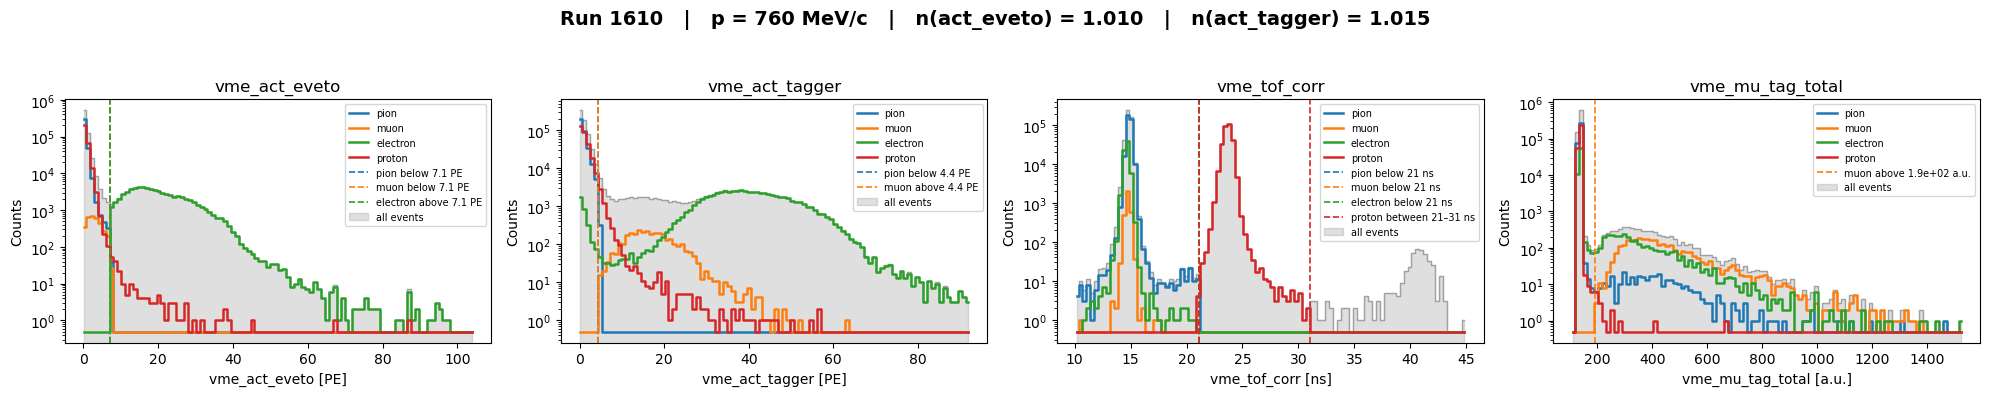

Loaded 751920 events across 107 batches  (454.0 s)


In [10]:
import time
import awkward as ak

loader.apply_mPMT_data_quality_cuts()
loader.apply_vme_event_quality_cuts()
loader.apply_t5_event_quality_cuts()

# Enable parquet output for the selections you want to save.
# Default filename is "<particle>.parquet". Pass a path to override.
pion_sel.enable_parquet_output(f"run{run_number}_pions.parquet")
muon_sel.enable_parquet_output(f"run{run_number}_muons.parquet")
ele_sel.enable_parquet_output(f"run{run_number}_electrons.parquet")

selections = [pion_sel, muon_sel, ele_sel, proton_sel]
monitor    = SelectionMonitor(selections, update_every=10, vme_run_info=vme_run_info)

start_time = time.time()
n_windows_passing = 0

for i_batch, batch in enumerate(loader.iterate(verbose=False, step_size="100 MB")):
    n_windows_passing += len(batch)
    monitor.update(batch)
    for sel in selections:
        sel._write_to_parquet(batch[sel.mask(batch)])

for sel in selections:
    sel.close_parquet_writer()

monitor.show()
print(f"Loaded {n_windows_passing} events across {i_batch+1} batches  "
      f"({time.time() - start_time:.1f} s)")

In [11]:
# Read back the saved muon events and inspect them.
# The same pattern works for pions (pion_sel._parquet_path) and electrons.
muons = ak.from_parquet(muon_sel._parquet_path)

print(f"Total muons saved : {len(muons)}")
print(f"Mean corrected TOF: {float(ak.mean(muons['vme_tof_corr'])):.2f} ns")
print(f"Mean act_eveto    : {float(ak.mean(muons['vme_act_eveto'])):.3f} PE")
print(f"Mean act_tagger   : {float(ak.mean(muons['vme_act_tagger'])):.3f} PE")


Total muons saved : 3263
Mean corrected TOF: 14.72 ns
Mean act_eveto    : 2.869 PE
Mean act_tagger   : 17.284 PE


Get the good PMT list (by mPMT slot and pmt position). Any hit which is not from a good channel is be masked. This is useful for determining which channels are reading out stably for comparison to monte carlo.

In [12]:
#get the good PMTs slot and position
good_wcte_mpmt_slots, good_wcte_pmt_pos = loader.get_good_wcte_pmts()
print(good_wcte_mpmt_slots,good_wcte_pmt_pos)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..., 81, 81, 81, 81, 81, 81, 81, 81, 81, 81] [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, ..., 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]


In [13]:
print("Get the configuration data from the merged file:")
config = loader.get_configuration()
print(config)

print("Get the data quality metrics from the merged file:")
dqm = loader.get_data_quality_metrics()
print(dqm)

print("Get the data quality metrics from the merged file:")
dqm = loader.get_data_quality_metrics()
print(dqm)

print("Get the vme_analysis_scalar_results from the merged file:")
vme_scalar_results = loader.get_vme_analysis_scalar_results()
print(vme_scalar_results)

print("Get the vme_analysis_scalar_results from the merged file:")
vme_run_info = loader.get_vme_analysis_run_info()
print(vme_run_info)

Get the configuration data from the merged file:
{run_configuration: 'Good_mpmt_beam_v43', good_wcte_pmts: [0, ...], ...}
Get the data quality metrics from the merged file:
{n_good_pmt_channels: 1562, n_triggers: 1136955, n_bad_triggers: 169195, ...}
Get the data quality metrics from the merged file:
{n_good_pmt_channels: 1562, n_triggers: 1136955, n_bad_triggers: 169195, ...}
Get the vme_analysis_scalar_results from the merged file:
{act_eveto_cut: 7.14, act_tagger_cut: 4.44, proton_tof_cut: 21.1, ...}
Get the vme_analysis_scalar_results from the merged file:
{run_number: 1610, run_momentum: 760, n_eveto: 1.01, n_tagger: 1.01, ...}
